# Customer Churn Prediction & Customer Segmentation

## 05 — Model Evaluation, Threshold Optimization & Explainability

### Objective

The previous notebook compared several classification models and identified an initial best candidate.

However, a model with a good F1-score is not automatically a good business decision system.

In this notebook we will answer:

1. How does model performance change when the probability threshold changes?
2. What happens if we prioritize recall?
3. What happens if we prioritize precision?
4. Which threshold gives us a sensible business trade-off?
5. Where is the model making mistakes?
6. Which features are most important to the model?
7. Is the selected model strong enough to move forward?

> **The model produces probabilities. The business needs decisions. Threshold optimization is the bridge between the two.**

## 1. Import libraries

We use the same modelling and evaluation tools as the previous notebook.

We also use permutation importance for model explainability. It measures how much model performance changes when the information in one feature is disrupted.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from sklearn.inspection import permutation_importance

## 2. Recreate the modelling dataset

For reproducibility, we rebuild the same preparation steps used in the modelling notebook.

The important requirement is that the same feature definitions and train/test split are used consistently.

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Customer-Churn.csv"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

df = pd.read_csv(RAW_DATA_PATH)

working_df = df.copy()

print(
    f"Raw dataset loaded: "
    f"{working_df.shape[0]:,} rows × {working_df.shape[1]} columns"
)

Raw dataset loaded: 7,043 rows × 21 columns


In [3]:
# Clean TotalCharges.

total_charges_numeric = pd.to_numeric(
    working_df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

missing_total_charges = total_charges_numeric.isnull()

working_df["TotalCharges"] = total_charges_numeric

working_df.loc[
    missing_total_charges,
    "TotalCharges"
] = (
    working_df.loc[
        missing_total_charges,
        "tenure"
    ]
    * working_df.loc[
        missing_total_charges,
        "MonthlyCharges"
    ]
)

# Create the same engineered features.

working_df["AverageMonthlySpend"] = (
    working_df["TotalCharges"]
    / working_df["tenure"].clip(lower=1)
)

working_df["IsNewCustomer"] = (
    working_df["tenure"] <= 12
).astype(int)

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

working_df["ServiceCount"] = 0

for column in service_columns:
    working_df["ServiceCount"] += (
        working_df[column] == "Yes"
    ).astype(int)

In [4]:
# Keep customer IDs for later error analysis.
customer_ids = working_df["customerID"].copy()

# Remove the identifier from model features.
working_df = working_df.drop(
    columns=["customerID"]
)

# Encode the target.
working_df["Churn"] = (
    working_df["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

X = working_df.drop(
    columns=["Churn"]
)

y = working_df["Churn"]

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

C:\Users\Aman\AppData\Local\Temp\ipykernel_22700\3358897434.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## 3. Recreate the train/test split

We use the same `random_state` and stratification strategy as the modelling notebook.

This is important because changing the split would make the model comparison from the previous stage impossible to reproduce exactly.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 5,634
Test rows: 1,409


## 4. Build the preprocessing pipeline

The preprocessing is fitted only on the training data.

The test set remains unseen during preprocessing fitting.

In [6]:
numerical_preprocessor = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ]
)

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Processed training shape: (5634, 48)
Processed test shape: (1409, 48)


# Part A — Rebuild the candidate models

## 5. Train the candidate models

We reproduce the same baseline configurations from the previous modelling stage.

This lets us perform a deeper evaluation without depending on notebook state.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    )
}

trained_models = {}

model_probabilities = {}

model_predictions = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_processed,
        y_train
    )

    trained_models[model_name] = model

    model_probabilities[model_name] = (
        model.predict_proba(
            X_test_processed
        )[:, 1]
    )

    model_predictions[model_name] = (
        model.predict(
            X_test_processed
        )
    )

print("All candidate models trained.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training CatBoost...
All candidate models trained.


# Part B — ROC-AUC and Precision-Recall behaviour

## 6. Compare ROC curves

ROC-AUC is useful for measuring ranking quality across different classification thresholds.

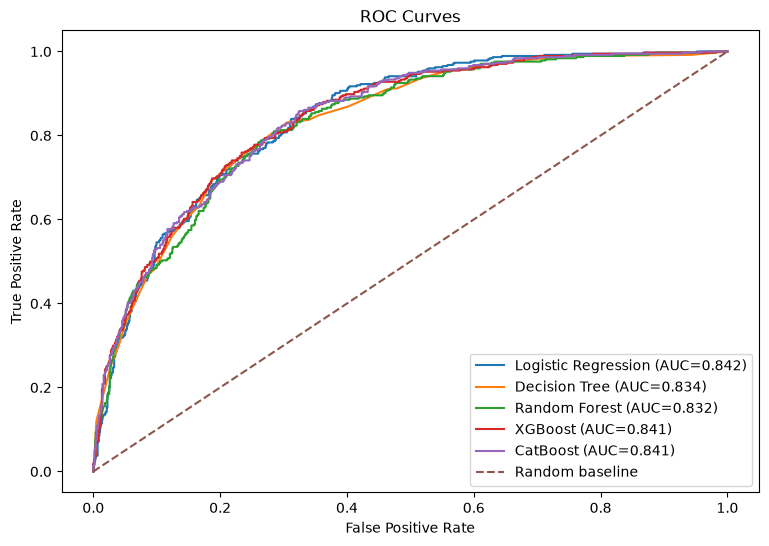

In [8]:
plt.figure(figsize=(9, 6))

for model_name, probabilities in model_probabilities.items():

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

## 7. Precision-Recall curve

For a churn problem, the precision-recall relationship can be particularly useful because the positive class represents customers who churn.

The curve shows what happens to precision as we try to identify more churners.

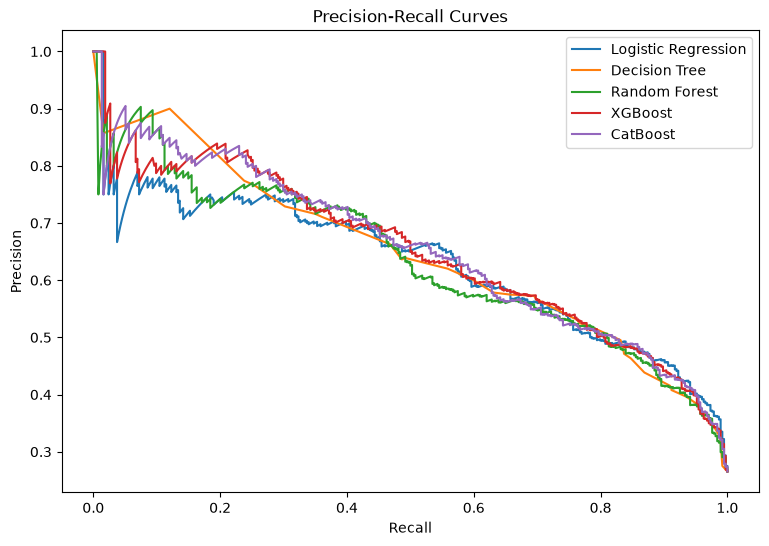

In [9]:
plt.figure(figsize=(9, 6))

for model_name, probabilities in model_probabilities.items():

    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_test,
            probabilities
        )
    )

    plt.plot(
        recall_values,
        precision_values,
        label=model_name
    )

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()

# Part C — Select the candidate for threshold optimization

## 8. Initial selection

We use ROC-AUC as a ranking-quality signal and F1 at the default threshold as a balanced screening metric.

For the deeper threshold analysis, we select the model with the strongest F1 from the initial comparison.

In [10]:
initial_scores = {}

for model_name, probabilities in model_probabilities.items():

    default_predictions = (
        probabilities >= 0.50
    ).astype(int)

    initial_scores[model_name] = {
        "Precision": precision_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            default_predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        )
    }

initial_comparison = (
    pd.DataFrame(initial_scores)
    .T
    .sort_values("F1", ascending=False)
)

initial_comparison.round(4)

,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.6645,0.5348,0.5926,0.8417
CatBoost,0.6655,0.5160,0.5813,0.8412
XGBoost,0.6483,0.5027,0.5663,0.8413
Random Forest,0.6327,0.4973,0.5569,0.8318
Decision Tree,0.6389,0.4920,0.5559,0.8340


In [11]:
best_model_name = initial_comparison["F1"].idxmax()

best_model = trained_models[
    best_model_name
]

best_probabilities = model_probabilities[
    best_model_name
]

print(
    "Model selected for threshold analysis:",
    best_model_name
)

Model selected for threshold analysis: Logistic Regression


# Part D — Threshold optimization

## 9. Why the default threshold is not automatically correct

Most binary classifiers use:

```text
Probability >= 0.50 → Churn
Probability < 0.50  → No Churn
```

But the business may prefer to catch more potential churners even if that means contacting some customers who would not have churned.

That means the threshold should be treated as a **business decision**, not a universal constant.

## 10. Evaluate a range of thresholds

We will test thresholds from 0.10 to 0.90.

For each threshold we calculate:

- Precision
- Recall
- F1-score
- Number of customers flagged as churn risk

This lets us see the practical trade-off.

In [12]:
threshold_values = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in threshold_values:

    threshold_predictions = (
        best_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    customers_flagged = (
        threshold_predictions == 1
    ).sum()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Customers_Flagged": customers_flagged
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(3)

,Threshold,Precision,Recall,F1,Customers_Flagged
0,0.10,0.403,0.941,0.565,873
1,0.15,0.441,0.920,0.596,780
2,0.20,0.478,0.861,0.615,674
3,0.25,0.494,0.802,0.612,607
4,0.30,0.528,0.754,0.621,534
5,0.35,0.557,0.709,0.624,476
6,0.40,0.582,0.655,0.616,421
7,0.45,0.601,0.591,0.596,368
8,0.50,0.664,0.535,0.593,301
9,0.55,0.676,0.452,0.542,250


## 11. Visualize the threshold trade-off

This is one of the most important plots in the project.

Moving the threshold lower usually increases recall but reduces precision.

Moving it higher usually increases precision but reduces recall.

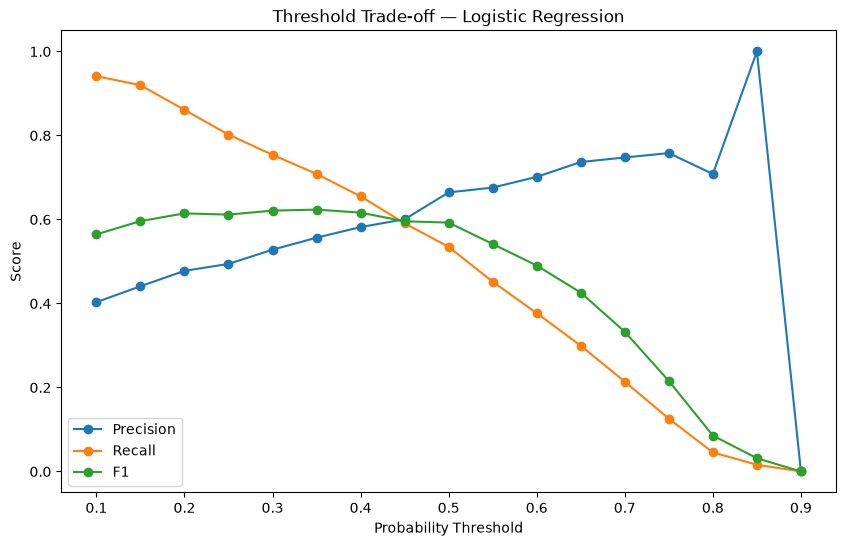

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.title(
    f"Threshold Trade-off — {best_model_name}"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend()

plt.show()

## 12. Find the threshold with the highest F1

F1 is useful as a balanced statistical criterion.

It is not necessarily the final business threshold, but it gives us an evidence-based starting point.

In [14]:
best_f1_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_f1_threshold = best_f1_row["Threshold"]

print(
    f"Threshold with highest F1: "
    f"{best_f1_threshold:.2f}"
)

display(
    best_f1_row.to_frame().T
)

Threshold with highest F1: 0.35


,Threshold,Precision,Recall,F1,Customers_Flagged
5,0.35,0.556723,0.708556,0.623529,476.0


# Part E — Business-oriented threshold thinking

## 13. Define a simple retention-cost scenario

A threshold cannot be selected responsibly without considering what the business values.

For illustration, we create a simple scenario:

- Missing a real churner = **₹1,000 expected business loss**
- Contacting a customer who would not churn = **₹100 retention cost**

These values are **assumptions for modelling the decision**, not claims about the actual company's economics.

In a real deployment, these values should come from the business.

In [15]:
FALSE_NEGATIVE_COST = 1000
FALSE_POSITIVE_COST = 100

print(
    "Assumed false-negative cost:",
    FALSE_NEGATIVE_COST
)

print(
    "Assumed false-positive cost:",
    FALSE_POSITIVE_COST
)

Assumed false-negative cost: 1000
Assumed false-positive cost: 100


## 14. Calculate expected cost at each threshold

For every threshold:

- False negatives represent churners we failed to identify.
- False positives represent customers who would receive unnecessary retention attention.

The objective is to find a threshold with a lower expected cost under our stated assumptions.

In [16]:
business_threshold_results = []

for threshold in threshold_values:

    predictions = (
        best_probabilities >= threshold
    ).astype(int)

    confusion = confusion_matrix(
        y_test,
        predictions
    )

    true_negative, false_positive, false_negative, true_positive = (
        confusion.ravel()
    )

    expected_cost = (
        false_negative * FALSE_NEGATIVE_COST
        + false_positive * FALSE_POSITIVE_COST
    )

    business_threshold_results.append({
        "Threshold": threshold,
        "False_Positives": false_positive,
        "False_Negatives": false_negative,
        "True_Positives": true_positive,
        "Expected_Cost": expected_cost
    })

business_threshold_results = pd.DataFrame(
    business_threshold_results
)

business_threshold_results.round(2)

,Threshold,False_Positives,False_Negatives,True_Positives,Expected_Cost
0,0.10,521,22,352,74100
1,0.15,436,30,344,73600
2,0.20,352,52,322,87200
3,0.25,307,74,300,104700
4,0.30,252,92,282,117200
5,0.35,211,109,265,130100
6,0.40,176,129,245,146600
7,0.45,147,153,221,167700
8,0.50,101,174,200,184100
9,0.55,81,205,169,213100


In [17]:
best_business_row = business_threshold_results.loc[
    business_threshold_results["Expected_Cost"].idxmin()
]

business_optimal_threshold = (
    best_business_row["Threshold"]
)

print(
    f"Lowest-cost threshold under the assumed business costs: "
    f"{business_optimal_threshold:.2f}"
)

display(
    best_business_row.to_frame().T
)

Lowest-cost threshold under the assumed business costs: 0.15


,Threshold,False_Positives,False_Negatives,True_Positives,Expected_Cost
1,0.15,436.0,30.0,344.0,73600.0


### Important interpretation

The business-optimal threshold depends on the costs we assumed.

If the cost of missing a churner increases, the business will generally prefer a lower threshold and higher recall.

If retention campaigns become expensive, the business may prefer a higher threshold and stronger precision.

This is why threshold selection should be configurable in the production system.

# Part F — Final threshold decision

## 15. Compare default, F1-optimal and business-optimal thresholds

We now compare the three important reference points:

- 0.50 default threshold
- highest-F1 threshold
- lowest-cost threshold under our assumed business costs

In [18]:
thresholds_to_compare = [
    0.50,
    float(best_f1_threshold),
    float(business_optimal_threshold)
]

threshold_comparison = []

for threshold in thresholds_to_compare:

    predictions = (
        best_probabilities >= threshold
    ).astype(int)

    threshold_comparison.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Customers_Flagged": int(
            predictions.sum()
        )
    })

threshold_comparison = pd.DataFrame(
    threshold_comparison
).drop_duplicates(
    subset=["Threshold"]
)

threshold_comparison.round(4)

,Threshold,Precision,Recall,F1,Customers_Flagged
0,0.50,0.6645,0.5348,0.5926,301
1,0.35,0.5567,0.7086,0.6235,476
2,0.15,0.4410,0.9198,0.5962,780


### Decision

For the portfolio version of this project, we will retain the **business-oriented threshold** as the main decision threshold, while keeping the threshold configurable.

The exact threshold is not a universal truth. It should be recalculated if the business cost assumptions change.

# Part G — Error analysis

## 16. Inspect false positives and false negatives

A model score tells us *how often* the model is wrong.

Error analysis helps us understand *where and how* it is wrong.

This is especially useful for churn because false negatives and false positives have different business consequences.

In [19]:
final_threshold = business_optimal_threshold

final_predictions = (
    best_probabilities >= final_threshold
).astype(int)

test_results = X_test.copy()

test_results["Actual_Churn"] = y_test.values

test_results["Predicted_Churn"] = (
    final_predictions
)

test_results["Churn_Probability"] = (
    best_probabilities
)

test_results["Error_Type"] = "Correct"

test_results.loc[
    (test_results["Actual_Churn"] == 0)
    & (test_results["Predicted_Churn"] == 1),
    "Error_Type"
] = "False Positive"

test_results.loc[
    (test_results["Actual_Churn"] == 1)
    & (test_results["Predicted_Churn"] == 0),
    "Error_Type"
] = "False Negative"

test_results.loc[
    (test_results["Actual_Churn"] == 1)
    & (test_results["Predicted_Churn"] == 1),
    "Error_Type"
] = "True Positive"

test_results.loc[
    (test_results["Actual_Churn"] == 0)
    & (test_results["Predicted_Churn"] == 0),
    "Error_Type"
] = "True Negative"

test_results["customerID"] = customer_ids.loc[
    test_results.index
]

print(
    "Error distribution:"
)

display(
    test_results["Error_Type"]
    .value_counts()
    .to_frame("Customers")
)

Error distribution:


,Customers
Error_Type,
True Negative,599
False Positive,436
True Positive,344
False Negative,30


## 17. Inspect false negatives

False negatives are customers who actually churned but were not flagged.

These are especially important because they represent missed retention opportunities.

In [20]:
false_negative_customers = test_results[
    test_results["Error_Type"] == "False Negative"
].copy()

print(
    f"False negative customers: "
    f"{len(false_negative_customers):,}"
)

display(
    false_negative_customers[
        [
            "customerID",
            "tenure",
            "Contract",
            "MonthlyCharges",
            "TotalCharges",
            "Churn_Probability"
        ]
    ]
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
    .head(20)
)

False negative customers: 30


,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn_Probability
481,0447-BEMNG,48,Month-to-month,45.30,2145.00,0.148715
3240,8849-GYOKR,54,One year,106.55,5763.30,0.134432
3197,3523-QRQLL,22,One year,69.50,1498.20,0.127572
580,1218-VKFPE,12,Month-to-month,19.00,233.55,0.124593
4296,4489-SNOJF,35,Month-to-month,72.25,2568.55,0.121750
5884,4785-QRJHC,46,One year,59.90,2816.65,0.121533
4402,9039-RBEEE,39,Month-to-month,48.95,1880.85,0.120997
3672,9378-FXTIZ,54,One year,70.15,3715.65,0.117745
3534,2165-VOEGB,46,One year,105.20,4822.85,0.097342
3803,2533-QVMSK,61,Two year,94.10,5638.30,0.095445


## 18. Inspect false positives

False positives are customers flagged as churn risks who did not actually churn.

These customers matter because unnecessary retention actions have a cost.

In [21]:
false_positive_customers = test_results[
    test_results["Error_Type"] == "False Positive"
].copy()

print(
    f"False positive customers: "
    f"{len(false_positive_customers):,}"
)

display(
    false_positive_customers[
        [
            "customerID",
            "tenure",
            "Contract",
            "MonthlyCharges",
            "TotalCharges",
            "Churn_Probability"
        ]
    ]
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
    .head(20)
)

False positive customers: 436


,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn_Probability
4039,8161-QYMTT,7,Month-to-month,94.10,701.30,0.845248
3346,2545-EBUPK,2,Month-to-month,84.05,186.05,0.845099
935,6630-UJZMY,4,Month-to-month,83.25,308.05,0.833752
6574,6969-MVBAI,9,Month-to-month,90.10,816.80,0.812524
2519,4927-WWOOZ,2,Month-to-month,91.45,171.45,0.809912
2350,8739-XNIKG,5,Month-to-month,84.00,424.75,0.807155
352,4115-NZRKS,7,Month-to-month,89.15,574.35,0.806799
5839,2077-MPJQO,7,Month-to-month,75.40,533.05,0.786113
5627,9334-GWGOW,7,Month-to-month,74.85,485.25,0.781678
2493,8622-ZLFKO,6,Month-to-month,90.75,512.25,0.770314


### Error-analysis takeaway

False negatives and false positives should not simply be deleted or ignored.

They can reveal:

- customer groups the model struggles to distinguish
- overlapping customer behaviour
- missing features
- noisy observations
- possible opportunities for better feature engineering

We will use these observations if they suggest a clear improvement.

# Part H — Model explainability

## 19. Why explain the model?

A production churn model should not only produce a probability.

The business may ask:

> **Why was this customer considered high risk?**

We will first use permutation importance.

### What permutation importance does

For one feature, we randomly disrupt its values and measure how much model performance changes.

If model performance drops significantly, that feature was important to the model's predictions.

This gives us a model-level view of feature importance.

## 20. Calculate permutation importance

We evaluate importance on the held-out test set.

This is deliberately done after the model has been trained.

In [22]:
permutation_result = permutation_importance(
    best_model,
    X_test_processed,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_Std": permutation_result.importances_std
})

feature_importance = feature_importance.sort_values(
    "Importance_Mean",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance_Mean,Importance_Std
1,numerical__tenure,0.168671,0.013591
39,categorical__Contract_Month-to-month,0.063849,0.009992
19,categorical__InternetService_Fiber optic,0.057769,0.012072
41,categorical__Contract_Two year,0.052010,0.007213
2,numerical__MonthlyCharges,0.032580,0.011556
5,numerical__IsNewCustomer,0.030915,0.013487
4,numerical__AverageMonthlySpend,0.026079,0.009892
18,categorical__InternetService_DSL,0.025369,0.011533
21,categorical__OnlineSecurity_No,0.020063,0.006299
42,categorical__PaperlessBilling_No,0.020030,0.004955


## 21. Visualize the most important features

We display only the top features so that the plot remains interpretable.

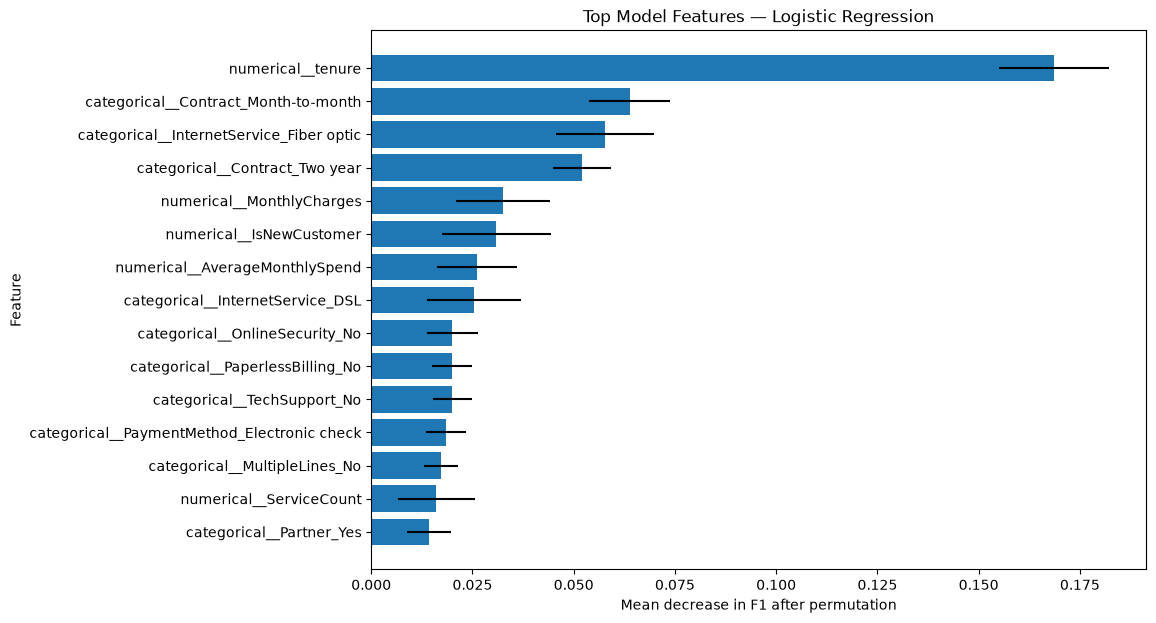

In [23]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance_Mean"],
    xerr=top_features["Importance_Std"]
)

plt.title(
    f"Top Model Features — {best_model_name}"
)

plt.xlabel(
    "Mean decrease in F1 after permutation"
)

plt.ylabel("Feature")

plt.show()

### Important caution

Feature importance does **not** mean causation.

If `Contract` is important, it does not prove that changing a customer's contract will prevent churn.

It means that the model relies on contract information when making predictions.

Business causality requires separate analysis.

# Part I — Final model evaluation

## 22. Final performance at the selected threshold

We now calculate the final metrics using the selected business threshold.

In [24]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    best_probabilities
)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_metrics

,Metric,Score
0,Accuracy,0.669269
1,Precision,0.441026
2,Recall,0.919786
3,F1,0.596187
4,ROC-AUC,0.841678


## 23. Final confusion matrix

This is the confusion matrix using the threshold selected from the business-cost analysis.

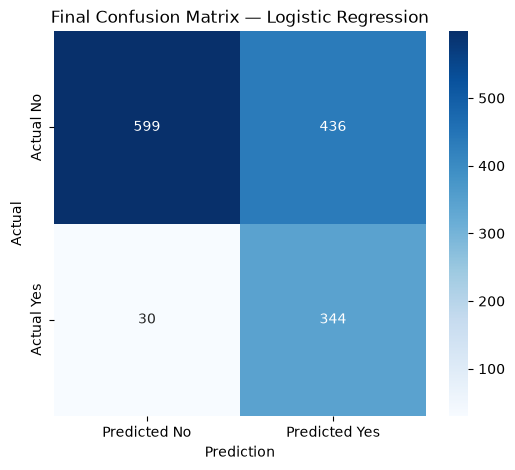

In [25]:
final_confusion = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted No",
        "Predicted Yes"
    ],
    yticklabels=[
        "Actual No",
        "Actual Yes"
    ]
)

plt.title(
    f"Final Confusion Matrix — {best_model_name}"
)

plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.show()

# 24. Final model decision

### What we have now

We have:

- compared multiple classification models
- selected an initial strong candidate
- evaluated ROC and precision-recall behaviour
- tested multiple probability thresholds
- compared statistical and business-oriented thresholds
- performed false-positive and false-negative analysis
- inspected model feature importance
- calculated final test metrics

### Production decision

The selected model and threshold should now be treated as the **current project candidate**, not as an unquestionable truth.

Before deployment, we should package:

- the preprocessing pipeline
- the trained model
- the selected threshold
- the feature definitions
- validation tests

### Important business note

The business-cost assumptions used here were illustrative.

For a real company, the threshold should be recalculated using actual:

- retention campaign cost
- expected customer lifetime value
- cost of losing a customer
- intervention success rate

### Next project stage

The next notebook will focus on **Customer Segmentation**.

We will build segments independently of the churn classifier and then profile them by:

- customer value
- tenure
- service adoption
- contract behaviour
- churn risk

The objective will be to turn clusters into **actionable customer groups**, not just assign arbitrary cluster labels.

> **A strong Data Science project ends with a decision and an action—not just a model score.**